# Project STAR with simultaneous RKHS and neural estimators

This notebook mirrors `dml_star_sequential.ipynb`, replacing the sequential nuisance fits with their simultaneous analogues: one `ApproxRKHS2IVCV` model or one `AGMM2L2` model per DML fit. The STAR-only TSLS oracle, full-sample and prior-score-subsample analyses, localized curves, and confidence-interval convention are unchanged. Output filenames are distinct from the sequential notebook.


In [1]:
# =========================================================
# Simultaneous long-term score estimates and localized curves for Project STAR
#
# =========================================================

# -----------------------
# Imports & configuration
# -----------------------
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator
import seaborn as sns
from contextlib import contextmanager
import time

# Limit BLAS/OpenMP threads to avoid oversubscription when joblib/pytorch also parallelize
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

from threadpoolctl import threadpool_limits
threadpool_limits(1)

from sklearn.linear_model import LogisticRegression

# RKHS
from nnpiv.rkhs import ApproxRKHS2IVCV

# NN/AGMM 
import torch
import torch.nn as nn
from nnpiv.neuralnet.agmm2 import AGMM2L2

# Linear
from nnpiv.tsls import tsls

# DML long-term
from nnpiv.semiparametrics import DML_longterm, DML_npiv


# -----------------------
# Reproducibility helpers
# -----------------------
def seed_everything(seed: int = 123) -> None:
    """Set seeds for reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(123)

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
try:
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
except Exception:
    pass

# --------------------------------
# Paths & high-level configuration
# --------------------------------
DATA_PATH = "../data/data_star.csv"
OUTDIR = "../output/"  # where to save CSVs and PNGs
os.makedirs(OUTDIR, exist_ok=True)

OUTCOME_LIST = [f"z_score{g}" for g in range(3, 9)]  # z_score3 .. z_score8
LOGIT_KW = dict(max_iter=2000)

# -----------------------
# Plotting configuration
# -----------------------
sns.set_style("white")
sns.set_palette("Set2")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

STAR_LEGEND_ORACLE = "Oracle: STAR (D, Y)"
STAR_LEGEND_LATENT = "Proposal: STAR (D, M) + NYC (D, M, Y)"
STAR_LEGEND_SURROGACY = "Proposal: STAR (D, M) + NYC (M, Y)"
HETERO_YLIM = (-0.5, 1.5)
HETERO_YTICKS = np.arange(-0.5, 1.51, 0.5)

# ---------------
# Model builders
# ---------------
def build_rkhs_model():
    """Return a fresh simultaneous Nyström RKHS model for each DML fit."""
    return ApproxRKHS2IVCV(
        kernel_approx="nystrom",
        n_components=400,
        kernel="rbf",
        gamma=0.001,
        delta_scale="auto",
        delta_exp=0.4,
        alpha_scales=np.array([0.1, 1.0, 10.0]),
        cv=5,
        expand_alpha_grid=False,
    )

def build_nn_model(p: float = 0.10, n_hidden: int = 100):
    """Return a fresh simultaneous AGMM2L2 model and its fit options."""
    def _get_learner(n_t):
        return nn.Sequential(
            nn.Dropout(p=p), nn.Linear(n_t, n_hidden), nn.LeakyReLU(),
            nn.Dropout(p=p), nn.Linear(n_hidden, 1),
        )

    def _get_adversary(n_z):
        return nn.Sequential(
            nn.Dropout(p=p), nn.Linear(n_z, n_hidden), nn.LeakyReLU(),
            nn.Dropout(p=p), nn.Linear(n_hidden, 1),
        )

    # With X1=None, X is a constant column and S is scalar:
    # A,D=[S,X] have two columns, while B,C=X have one.
    model = AGMM2L2(
        learnerh=_get_learner(1),
        learnerg=_get_learner(2),
        adversary1=_get_adversary(2),
        adversary2=_get_adversary(1),
    )
    fitargs = {
        "n_epochs": 500,
        "bs": 100,
        "learner_lr": 1e-4,
        "adversary_lr": 1e-4,
        "learner_l2": 1e-3,
        "adversary_l2": 1e-4,
        "device": DEVICE,
    }
    opts = {"burnin": 400}
    return model, fitargs, opts

# --------------
# Core routines
# --------------
def run_longterm_suite_single_Y(
    Y: np.ndarray,
    D: np.ndarray,
    S: np.ndarray,
    G: np.ndarray,
    ones: np.ndarray,
    mode: str,  # "rkhs" or "nn"
):
    """
    Run the two simultaneous proposals and the oracle for a single outcome:
      - Long-term latent unconfounded
      - Long-term surrogacy
      - Oracle (experimental NPIV)
    Returns: dict with coefficients/variances for each estimator.
    """
    # Build models fresh per outcome (avoid carrying fit state across outcomes)
    if mode == "rkhs":
        model = build_rkhs_model()
        dml_kwargs_common = dict(
            model1=model,
            nn_1=False,
            fitargs1=None,
            opts={"lin_degree": 1},
        )
    elif mode == "nn":
        model, fitargs, opts = build_nn_model()
        dml_kwargs_common = dict(
            model1=model,
            nn_1=True,
            fitargs1=fitargs,
            opts=opts,
            inner_n_jobs=1,
        )
    else:
        raise ValueError("mode must be 'rkhs' or 'nn'")

    # Long-term (latent)
    dml_latent = DML_longterm(
        Y, D, S, G,
        longterm_model="latent_unconfounded",
        sample_G="all",
        n_folds=5, n_rep=1, CHIM=False,
        prop_score=LogisticRegression(**LOGIT_KW),
        **dml_kwargs_common
    )
    coef_latent, var_latent, _ = dml_latent.dml()

    # Long-term (surrogacy)
    dml_surr = DML_longterm(
        Y, D, S, G,
        longterm_model="surrogacy",
        sample_G="all",
        n_folds=5, n_rep=1, CHIM=False,
        prop_score=LogisticRegression(**LOGIT_KW),
        **dml_kwargs_common
    )
    coef_surr, var_surr, _ = dml_surr.dml()

    # Oracle (experimental arm only)
    idx_exp = np.where(G.reshape(-1) == 0)[0]
    Y_exp = Y[idx_exp]
    D_exp = D[idx_exp]
    ones_exp = ones[idx_exp]
    dml_oracle = DML_npiv(
        Y_exp, D_exp, ones_exp, ones_exp,
        estimator="MR",
        model1=tsls(),
        modelq1=tsls(),
        n_folds=5, n_rep=1, CHIM=False,
        prop_score=LogisticRegression(**LOGIT_KW),
    )
    coef_or, var_or, _ = dml_oracle.dml()

    return dict(
        coef_latent=float(np.atleast_1d(coef_latent)[0]),
        var_latent=float(np.atleast_1d(var_latent)[0]),
        coef_surr=float(np.atleast_1d(coef_surr)[0]),
        var_surr=float(np.atleast_1d(var_surr)[0]),
        coef_oracle=float(np.atleast_1d(coef_or)[0]),
        var_oracle=float(np.atleast_1d(var_or)[0]),
        n_oracle=len(Y_exp),
    )

def run_longterm_grid(
    df: pd.DataFrame,
    outcome_cols: list[str],
    D_col: str,
    S_col: str,
    G_col: str,
    subset_mask: np.ndarray | None,
    mode: str,  # "rkhs" or "nn"
):
    """
    Run the suite across multiple outcomes and return a tidy results DataFrame.
    If subset_mask is provided, rows with False are dropped consistently across all variables.
    """
    if subset_mask is not None:
        dff = df.loc[subset_mask].copy()
    else:
        dff = df

    # Assemble arrays
    D = dff[[D_col]].values
    S = dff[[S_col]].values
    G = dff[[G_col]].values
    ones = np.ones((len(dff), 1), dtype=float)

    rows = []
    for ycol in outcome_cols:
        Y = dff[[ycol]].values
        res = run_longterm_suite_single_Y(Y, D, S, G, ones, mode=mode)
        rows.append({
            "Y_value": ycol,
            "Coefficient Latent": res["coef_latent"],
            "Variance Latent": res["var_latent"],
            "Coefficient Surrogacy": res["coef_surr"],
            "Variance Surrogacy": res["var_surr"],
            "Coefficient Oracle": res["coef_oracle"],
            "Variance Oracle": res["var_oracle"],
            "sample_G_proposed": "all",
            "n": len(dff),  # backward-compatible alias for n_proposed
            "n_proposed": len(dff),
            "n_oracle": res["n_oracle"],
        })
    return pd.DataFrame(rows)

# -----------
# Plot helper
# -----------
def plot_results(results: pd.DataFrame, title: str, out_png: str):
    """
    Errorbar plot across long-term horizons (z_score3..8).
    Uses 95% normal CIs with the proposed-sample and STAR-oracle counts separately.
    """
    n_proposed = float(results["n_proposed"].iloc[0])
    n_oracle = float(results["n_oracle"].iloc[0])
    x = np.arange(3, 9)  # horizons 3..8
    halfwidth_oracle = 1.96 * np.sqrt(results["Variance Oracle"].to_numpy() / n_oracle)
    halfwidth_latent = 1.96 * np.sqrt(results["Variance Latent"].to_numpy() / n_proposed)
    halfwidth_surrogacy = 1.96 * np.sqrt(results["Variance Surrogacy"].to_numpy() / n_proposed)

    plt.figure(figsize=(7, 3))
    plt.errorbar(
        x - 0.1,
        results["Coefficient Oracle"],
        yerr=halfwidth_oracle,
        elinewidth=2.5, capthick=2.5, capsize=6, markersize=8, markeredgewidth=1.8, fmt="x", label=STAR_LEGEND_ORACLE,
    )
    plt.errorbar(
        x,
        results["Coefficient Latent"],
        yerr=halfwidth_latent,
        elinewidth=2.5, capthick=2.5, capsize=6, markersize=8, markeredgewidth=1.8, fmt=".", label=STAR_LEGEND_LATENT,
    )
    plt.errorbar(
        x + 0.1,
        results["Coefficient Surrogacy"],
        yerr=halfwidth_surrogacy,
        elinewidth=2.5, capthick=2.5, capsize=6, markersize=8, markeredgewidth=1.8, fmt="^", label=STAR_LEGEND_SURROGACY,
    )

    coefficients = [
        results["Coefficient Oracle"].to_numpy(),
        results["Coefficient Latent"].to_numpy(),
        results["Coefficient Surrogacy"].to_numpy(),
    ]
    halfwidths = [halfwidth_oracle, halfwidth_latent, halfwidth_surrogacy]
    lower = min(0.0, min(np.nanmin(coef - halfwidth) for coef, halfwidth in zip(coefficients, halfwidths)))
    upper = max(0.0, max(np.nanmax(coef + halfwidth) for coef, halfwidth in zip(coefficients, halfwidths)))
    span = max(upper - lower, 0.05)
    padding = 0.08 * span

    ax = plt.gca()
    axis_lower = lower - padding if lower < 0 else 0.0
    axis_upper = upper + padding
    locator = MaxNLocator(nbins=6, steps=[1, 2, 2.5, 5, 10])
    ticks = locator.tick_values(axis_lower, axis_upper)
    ax.set_ylim(ticks[0], ticks[-1])
    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.tick_params(axis="y", labelsize=12)
    plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
    sns.despine()

    plt.xticks(x, [str(i) for i in x], fontsize=18)
    plt.xlabel("Long term horizon", fontsize=18)
    plt.ylabel("Long term effect", fontsize=18)

    print(f"[PLOT] {title}")
    plt.legend(frameon=False, loc=(.4, .8), fontsize=13)
    plt.tight_layout()
    plt.savefig(out_png, dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Saved figure -> {out_png}")

@contextmanager
def timer(label: str):
    t0 = time.perf_counter()
    try:
        yield
    finally:
        dt = time.perf_counter() - t0
        mins, secs = divmod(dt, 60)
        print(f"[TIMING] {label} finished in {int(mins)}m {secs:05.2f}s")

# ---------- System / resource banner ----------
def print_system_resources():
    import sys, os, platform, datetime
    try:
        import psutil
    except Exception:
        psutil = None
    from threadpoolctl import threadpool_info
    import numpy as np
    import sklearn
    try:
        import torch
    except Exception:
        torch = None

    print("="*72)
    print(f"Session started: {datetime.datetime.now().isoformat(timespec='seconds')}")
    print(f"Python: {sys.version.split()[0]}  |  OS: {platform.system()} {platform.release()} ({platform.machine()})")
    # CPU / RAM
    logical = os.cpu_count()
    physical = None
    if psutil:
        try:
            physical = psutil.cpu_count(logical=False)
        except Exception:
            physical = None
    line = f"CPU cores: {logical}"
    if physical:
        line += f" (physical: {physical})"
    print(line)
    if psutil:
        try:
            mem_gb = psutil.virtual_memory().total / (1024**3)
            print(f"RAM: {mem_gb:.1f} GB")
        except Exception:
            pass

    # BLAS/OpenMP threading + libraries
    env_keys = ["OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","VECLIB_MAXIMUM_THREADS","NUMEXPR_NUM_THREADS"]
    env_summary = ", ".join([f"{k}={os.environ.get(k,'-')}" for k in env_keys])
    print(f"Thread env: {env_summary}")
    try:
        infos = threadpool_info()
        if infos:
            print("Threadpool libraries:")
            for lib in infos:
                libname = lib.get("internal_api", lib.get("prefix", ""))
                nthreads = lib.get("num_threads", "?")
                fname = lib.get("filename", "")
                print(f"  - {libname:8s}  threads={nthreads}  lib={os.path.basename(fname)}")
    except Exception:
        pass

    # Packages
    print(f"NumPy: {np.__version__}  |  scikit-learn: {sklearn.__version__}")

    # GPU (PyTorch)
    if torch is not None:
        cuda_ok = torch.cuda.is_available()
        print(f"PyTorch: {torch.__version__}  |  CUDA available: {cuda_ok}")
        if cuda_ok:
            ngpu = torch.cuda.device_count()
            print(f"GPUs: {ngpu}")
            for i in range(ngpu):
                name = torch.cuda.get_device_name(i)
                cap  = torch.cuda.get_device_capability(i)
                print(f"  - [{i}] {name}  capability={cap[0]}.{cap[1]}")
            try:
                torch.set_num_threads(1)
                torch.set_num_interop_threads(1)
            except Exception:
                pass
    else:
        print("PyTorch: not installed")

    print("="*72)

In [2]:
# Print system resources
print_system_resources()

Session started: 2026-08-05T19:19:02
Python: 3.14.4  |  OS: Darwin 25.5.0 (arm64)
CPU cores: 18 (physical: 18)
RAM: 64.0 GB
Thread env: OMP_NUM_THREADS=1, OPENBLAS_NUM_THREADS=1, MKL_NUM_THREADS=1, VECLIB_MAXIMUM_THREADS=1, NUMEXPR_NUM_THREADS=1
Threadpool libraries:
  - openmp    threads=1  lib=
  - openmp    threads=1  lib=
NumPy: 2.3.2  |  scikit-learn: 1.7.2
PyTorch: 2.11.0  |  CUDA available: False


Rep: 1


100%|██████████| 5/5 [00:04<00:00,  1.04it/s]


Rep: 1


100%|██████████| 5/5 [00:05<00:00,  1.17s/it]


Rep: 1


...

Rep: 1


100%|██████████| 5/5 [00:05<00:00,  1.17s/it]


Rep: 1


100%|██████████| 5/5 [00:00<00:00, 188.50it/s]


[TIMING] Simultaneous RKHS — Full Sample finished in 1m 05.77s
Saved RKHS -> ../output/longterm_star_simultaneous_rkhs.csv
[PLOT] Simultaneous RKHS — Full Sample


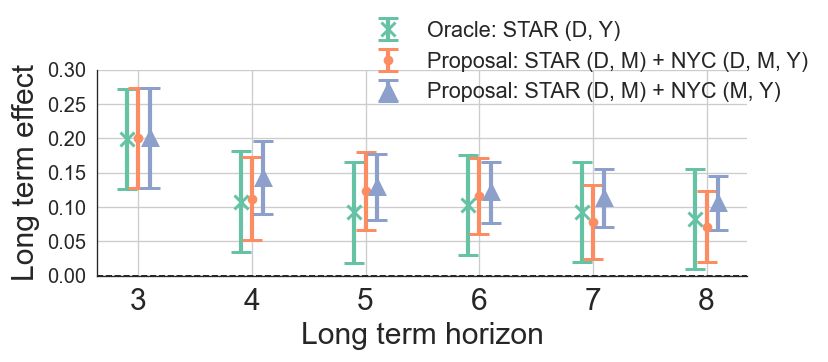

Saved figure -> ../output/plot_longterm_star_simultaneous_rkhs.png


In [3]:
# --------
# Run all
# --------
# 1) Load data once. The source file is block-ordered by G, so shuffle
# deterministically to keep both joint-moment subsets in every inner CV fold.
df = (
    pd.read_csv(DATA_PATH)
    .sample(frac=1, random_state=123)
    .reset_index(drop=True)
)

# Shared columns
D_col = "D"
S_col = "z_score3"     # mediator/surrogate at t=3
G_col = "G"

# ----------------------------
# A) Simultaneous RKHS — full sample
# ----------------------------
with timer("Simultaneous RKHS — Full Sample"):
    results_rkhs_full = run_longterm_grid(
        df=df,
        outcome_cols=OUTCOME_LIST,
        D_col=D_col, S_col=S_col, G_col=G_col,
        subset_mask=None,
        mode="rkhs",
    )
csv_rkhs_full = os.path.join(OUTDIR, "longterm_star_simultaneous_rkhs.csv")
results_rkhs_full.to_csv(csv_rkhs_full, index=False)
print(f"Saved RKHS -> {csv_rkhs_full}")
plot_results(results_rkhs_full, title="Simultaneous RKHS — Full Sample", out_png=os.path.join(OUTDIR, "plot_longterm_star_simultaneous_rkhs.png"))

Rep: 1


100%|██████████| 5/5 [00:04<00:00,  1.08it/s]


Rep: 1


100%|██████████| 5/5 [00:05<00:00,  1.10s/it]


Rep: 1


...

Rep: 1


100%|██████████| 5/5 [00:05<00:00,  1.13s/it]


Rep: 1


100%|██████████| 5/5 [00:00<00:00, 193.27it/s]

[TIMING] Simultaneous RKHS — Subsample finished in 1m 01.92s
Saved RKHS (subsample) -> ../output/longterm_star_simultaneous_rkhs_subsample.csv
[PLOT] Simultaneous RKHS — Subsample (non-missing prior score)


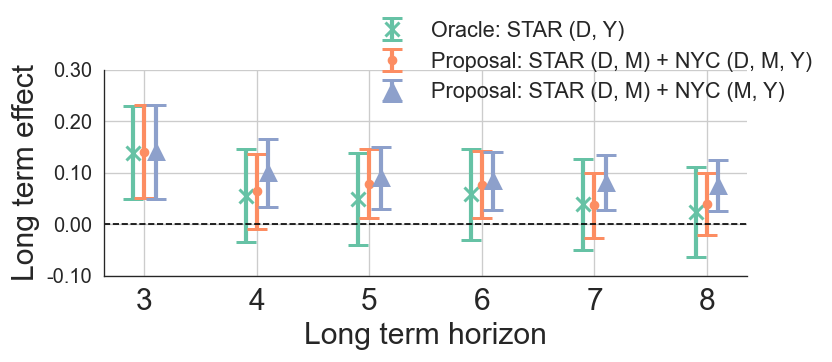

Saved figure -> ../output/plot_longterm_star_simultaneous_rkhs_subsample.png


In [4]:
# -------------------------------------------------------
# B) Simultaneous RKHS — subsample (drop rows with NaN on z_score_prior)
# -------------------------------------------------------
mask_prior = ~df["z_score_prior"].isna().values
with timer("Simultaneous RKHS — Subsample"):
    results_rkhs_sub = run_longterm_grid(
        df=df,
        outcome_cols=OUTCOME_LIST,
        D_col=D_col, S_col=S_col, G_col=G_col,
        subset_mask=mask_prior,
        mode="rkhs",
    )
csv_rkhs_sub = os.path.join(OUTDIR, "longterm_star_simultaneous_rkhs_subsample.csv")
results_rkhs_sub.to_csv(csv_rkhs_sub, index=False)
print(f"Saved RKHS (subsample) -> {csv_rkhs_sub}")
plot_results(results_rkhs_sub, title="Simultaneous RKHS — Subsample (non-missing prior score)", out_png=os.path.join(OUTDIR, "plot_longterm_star_simultaneous_rkhs_subsample.png"))

Rep: 1


100%|██████████| 5/5 [04:56<00:00, 59.29s/it]


Rep: 1


100%|██████████| 5/5 [09:56<00:00, 119.29s/it]


Rep: 1


...

Rep: 1


100%|██████████| 5/5 [09:34<00:00, 114.91s/it]


Rep: 1


100%|██████████| 5/5 [00:00<00:00, 197.99it/s]

[TIMING] Simultaneous AGMM2L2 — Full Sample finished in 89m 05.92s
Saved NN -> ../output/longterm_star_simultaneous_nn.csv
[PLOT] Simultaneous NN (AGMM2L2) — Full Sample


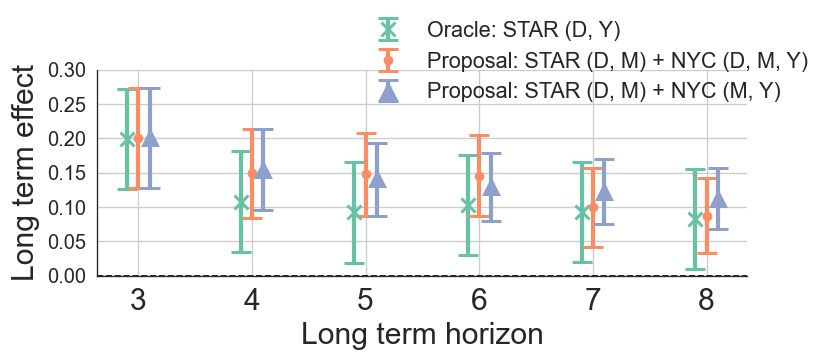

Saved figure -> ../output/plot_longterm_star_simultaneous_nn.png


In [5]:
# ----------------------------
# C) Simultaneous NN (AGMM2L2) — full sample
# ----------------------------
with timer("Simultaneous AGMM2L2 — Full Sample"):
    results_nn_full = run_longterm_grid(
        df=df,
        outcome_cols=OUTCOME_LIST,
        D_col=D_col, S_col=S_col, G_col=G_col,
        subset_mask=None,
    mode="nn",
    )
csv_nn_full = os.path.join(OUTDIR, "longterm_star_simultaneous_nn.csv")
results_nn_full.to_csv(csv_nn_full, index=False)
print(f"Saved NN -> {csv_nn_full}")
plot_results(results_nn_full, title="Simultaneous NN (AGMM2L2) — Full Sample", out_png=os.path.join(OUTDIR, "plot_longterm_star_simultaneous_nn.png"))

Rep: 1


100%|██████████| 5/5 [04:07<00:00, 49.46s/it]


Rep: 1


100%|██████████| 5/5 [08:10<00:00, 98.01s/it]


Rep: 1


...

Rep: 1


100%|██████████| 5/5 [08:08<00:00, 97.71s/it]


Rep: 1


100%|██████████| 5/5 [00:00<00:00, 173.28it/s]

[TIMING] Simultaneous AGMM2L2 — Subsample finished in 74m 00.41s
Saved NN (subsample) -> ../output/longterm_star_simultaneous_nn_subsample.csv
[PLOT] Simultaneous NN (AGMM2L2) — Subsample (non-missing prior score)


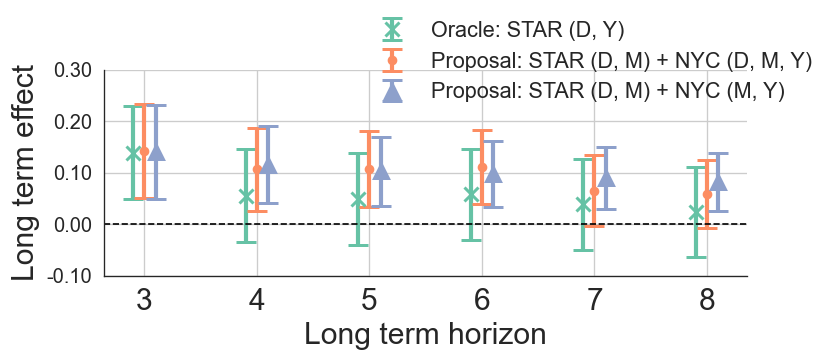

Saved figure -> ../output/plot_longterm_star_simultaneous_nn_subsample.png


In [6]:
# -------------------------------------------------------
# D) Simultaneous NN (AGMM2L2) — subsample (same mask as RKHS subsample)
# -------------------------------------------------------
with timer("Simultaneous AGMM2L2 — Subsample"):
    results_nn_sub = run_longterm_grid(
        df=df,
        outcome_cols=OUTCOME_LIST,
        D_col=D_col, S_col=S_col, G_col=G_col,
        subset_mask=mask_prior,
        mode="nn",
    )
csv_nn_sub = os.path.join(OUTDIR, "longterm_star_simultaneous_nn_subsample.csv")
results_nn_sub.to_csv(csv_nn_sub, index=False)
print(f"Saved NN (subsample) -> {csv_nn_sub}")
plot_results(results_nn_sub, title="Simultaneous NN (AGMM2L2) — Subsample (non-missing prior score)", out_png=os.path.join(OUTDIR, "plot_longterm_star_simultaneous_nn_subsample.png"))

In [7]:

# =========================================================
#    Finite-bandwidth localized score curves over prior ability
# =========================================================

def _bw_silverman_1d(V: np.ndarray) -> float:
    IQR = np.percentile(V, 75, axis=0) - np.percentile(V, 25, axis=0)
    A = np.minimum(np.std(V, axis=0), IQR / 1.349)
    n = V.shape[0]
    return (0.9 * np.asarray(A).squeeze() * (n ** -0.2)).item()

def run_heterogeneous_grid(
    df: pd.DataFrame,
    outcome_cols: list[str],
    mode: str,                 # "rkhs" or "nn"
    loc_kernel: str = "epa",
    percentiles = np.arange(5, 100, 10),
):
    """
    For each outcome, compute localized long-term score curves across pooled prior-ability percentiles.
    Uses DML_longterm with (V, v_values) for Surrogacy & Latent, and one localized
    DML_npiv fit in the experimental arm for the oracle (same grid and bandwidth).
    Produces one plot per outcome and returns a tidy DataFrame of all results.
    """
    # Keep all STAR and NYC observations with non-missing prior score for nuisance estimation
    mask = ~df["z_score_prior"].isna().values
    dff = df.loc[mask].copy()

    # Core arrays
    D = dff[["D"]].values
    S = dff[["z_score3"]].values
    G = dff[["G"]].values
    V = dff[["z_score_prior"]].values
    prop = LogisticRegression(**LOGIT_KW)

    # Proposed curves use the pooled nonmissing-prior sample for their grid and bandwidth
    idx_exp = np.where(G.reshape(-1) == 0)[0]
    V_exp = V[idx_exp]
    v_values = np.percentile(V, percentiles)
    bw = _bw_silverman_1d(V)

    # Choose backend
    if mode == "rkhs":
        model = build_rkhs_model()
        dml_common = dict(
            model1=model,
            nn_1=False,
            fitargs1=None,
            opts={"lin_degree": 1},
        )
    elif mode == "nn":
        model, fitargs, opts = build_nn_model()
        dml_common = dict(
            model1=model,
            nn_1=True,
            fitargs1=fitargs,
            opts=opts,
            inner_n_jobs=1,
        )
    else:
        raise ValueError("mode must be 'rkhs' or 'nn'")

    all_rows = []

    for ycol in outcome_cols:
        Y = dff[[ycol]].values

        # Prior ability determines localization weights but is excluded from nuisance covariates
        dml_s = DML_longterm(
            Y, D, S, G,
            X1=None, V=V, v_values=v_values, include_V=False,
            estimator="MR", loc_kernel=loc_kernel, bw_loc=[bw],
            longterm_model="surrogacy",
            sample_G="all",
            n_folds=5, n_rep=1, CHIM=False, prop_score=prop,
            **dml_common
        )
        theta_s, cov_s, ci_s = dml_s.dml()
        var_s = np.diag(cov_s)

        dml_lu = DML_longterm(
            Y, D, S, G,
            X1=None, V=V, v_values=v_values, include_V=False,
            estimator="MR", loc_kernel=loc_kernel, bw_loc=[bw],
            longterm_model="latent_unconfounded",
            sample_G="all",
            n_folds=5, n_rep=1, CHIM=False, prop_score=prop,
            **dml_common
        )
        theta_lu, cov_lu, ci_lu = dml_lu.dml()
        var_lu = np.diag(cov_lu)

        # Oracle remains STAR-only; prior ability is used only for localization
        Y_exp, D_exp, V_exp = Y[idx_exp], D[idx_exp], V[idx_exp]
        ones_exp = np.ones_like(Y_exp)

        dml_or = DML_npiv(
            Y_exp, D_exp, ones_exp, ones_exp,
            X1=None, V=V_exp, v_values=v_values, include_V=False,
            estimator="MR", ci_type="pointwise",
            loc_kernel=loc_kernel, bw_loc=[bw],
            model1=tsls(), modelq1=tsls(),
            n_folds=5, n_rep=1, CHIM=False, prop_score=prop,
            verbose=False, opts={"lin_degree": 1}, random_seed=123
        )
        theta_or, cov_or, ci_or = dml_or.dml()
        var_or = np.diag(cov_or)

        # Collect rows
        for k, p in enumerate(percentiles):
            all_rows.append({
                "Outcome": ycol,
                "sample_G_proposed": "all",
                "include_V_proposed": False,
                "Percentile": p,
                "Theta_Oracle": theta_or[k],
                "Variance_Oracle": var_or[k],
                "Lower_CI_Oracle": ci_or[k, 0],
                "Upper_CI_Oracle": ci_or[k, 1],
                "Theta_Surrogate": theta_s[k],
                "Variance_Surrogate": var_s[k],
                "Lower_CI_Surrogate": ci_s[k, 0],
                "Upper_CI_Surrogate": ci_s[k, 1],
                "Theta_Latent_Unconfounded": theta_lu[k],
                "Variance_Latent_Unconfounded": var_lu[k],
                "Lower_CI_Latent_Unconfounded": ci_lu[k, 0],
                "Upper_CI_Latent_Unconfounded": ci_lu[k, 1],
            })

        # Plot per outcome (print label instead of title)
        plt.figure(figsize=(9, 3.8))
        sns.set_style("white")
        sns.set_palette("Set2")

        yhat_o = theta_or
        yerr_o = [yhat_o - ci_or[:, 0], ci_or[:, 1] - yhat_o]
        plt.errorbar(percentiles, yhat_o, yerr=yerr_o, marker="x", linestyle="-", linewidth=2, elinewidth=2.5, capsize=6, capthick=2.5, markersize=8, markeredgewidth=1.8,
                     label=STAR_LEGEND_ORACLE)

        shift = 0.5
        yhat_lu = theta_lu
        yerr_lu = [yhat_lu - ci_lu[:, 0], ci_lu[:, 1] - yhat_lu]
        plt.errorbar(np.array(percentiles) + shift, yhat_lu, yerr=yerr_lu, marker=".", linestyle="-", linewidth=2, elinewidth=2.5, capsize=6, capthick=2.5, markersize=8, markeredgewidth=1.8,
                     label=STAR_LEGEND_LATENT)

        yhat_s = theta_s
        yerr_s = [yhat_s - ci_s[:, 0], ci_s[:, 1] - yhat_s]
        plt.errorbar(np.array(percentiles) - shift, yhat_s, yerr=yerr_s, marker="^", linestyle="-", linewidth=2, elinewidth=2.5, capsize=6, capthick=2.5, markersize=8, markeredgewidth=1.8,
                     label=STAR_LEGEND_SURROGACY)

        plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
        plt.ylim(*HETERO_YLIM)
        plt.xticks(fontsize=18)
        plt.yticks(HETERO_YTICKS, fontsize=12)
        plt.xlabel("Prior ability (percentiles)", fontsize=18)
        plt.ylabel("Long term effect", fontsize=18)
        sns.despine()
        legend = plt.legend(
            loc="upper right",
            ncol=1,
            frameon=True,
            fancybox=False,
            edgecolor="0.4",
            fontsize=13,
            handlelength=1.8,
            borderpad=0.6,
            labelspacing=0.4,
        )
        legend.get_frame().set_alpha(0.95)
        legend.get_frame().set_linewidth(0.8)
        plt.tight_layout()

        out_png = os.path.join(OUTDIR, f"plot_heterogeneous_{ycol}_{loc_kernel}_simultaneous_{mode}.png")
        # Print which plot instead of setting a title:
        print(f"[PLOT] Heterogeneous — {mode.upper()} — Outcome: {ycol} -> {out_png}")
        plt.savefig(out_png, dpi=600, bbox_inches="tight")
        plt.show()
        print(f"Saved figure -> {out_png}")

    res = pd.DataFrame(all_rows)
    out_csv = os.path.join(OUTDIR, f"heterogeneous_star_simultaneous_{mode}.csv")
    res.to_csv(out_csv, index=False)
    print(f"Saved heterogeneous ({mode}) -> {out_csv}")
    return res


Rep: 1


100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


Rep: 1


100%|██████████| 5/5 [00:04<00:00,  1.11it/s]


[PLOT] Heterogeneous — RKHS — Outcome: z_score3 -> ../output/plot_heterogeneous_z_score3_gau_simultaneous_rkhs.png


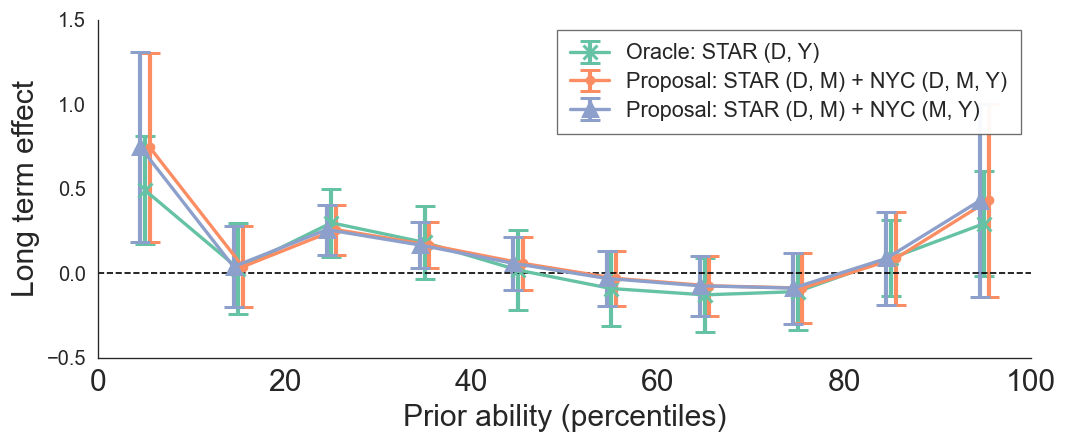

Saved figure -> ../output/plot_heterogeneous_z_score3_gau_simultaneous_rkhs.png
Rep: 1


100%|██████████| 5/5 [00:05<00:00,  1.10s/it]


Rep: 1


100%|██████████| 5/5 [00:04<00:00,  1.10it/s]


[PLOT] Heterogeneous — RKHS — Outcome: z_score4 -> ../output/plot_heterogeneous_z_score4_gau_simultaneous_rkhs.png


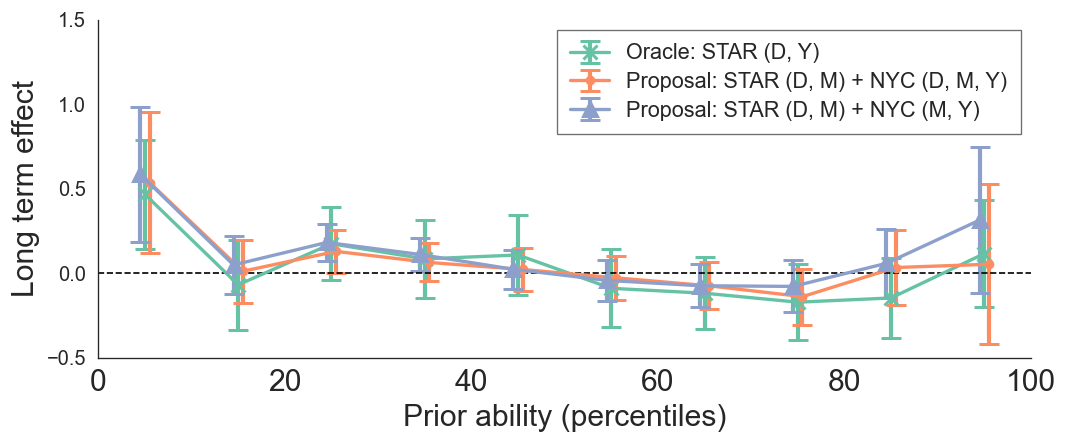

Saved figure -> ../output/plot_heterogeneous_z_score4_gau_simultaneous_rkhs.png
Rep: 1


100%|██████████| 5/5 [00:05<00:00,  1.10s/it]


Rep: 1


100%|██████████| 5/5 [00:04<00:00,  1.12it/s]


[PLOT] Heterogeneous — RKHS — Outcome: z_score5 -> ../output/plot_heterogeneous_z_score5_gau_simultaneous_rkhs.png


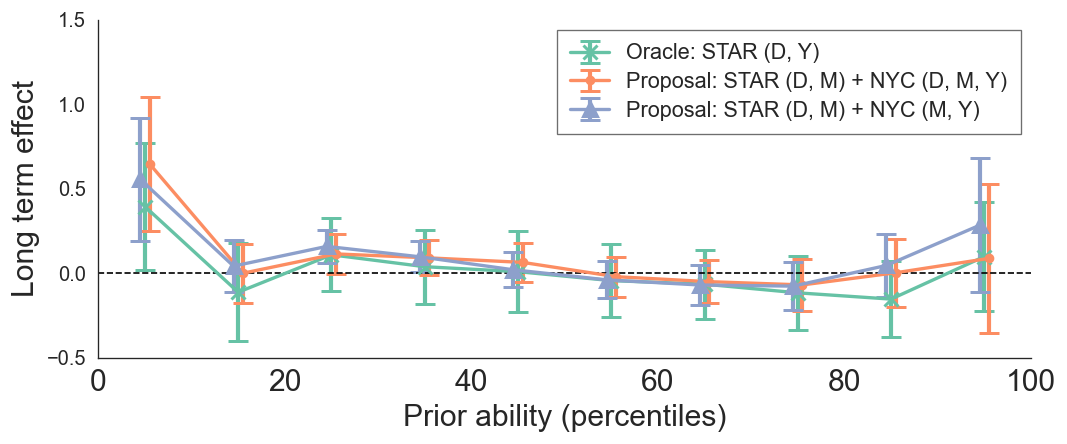

Saved figure -> ../output/plot_heterogeneous_z_score5_gau_simultaneous_rkhs.png
Rep: 1


100%|██████████| 5/5 [00:05<00:00,  1.09s/it]


Rep: 1


100%|██████████| 5/5 [00:04<00:00,  1.11it/s]


[PLOT] Heterogeneous — RKHS — Outcome: z_score6 -> ../output/plot_heterogeneous_z_score6_gau_simultaneous_rkhs.png


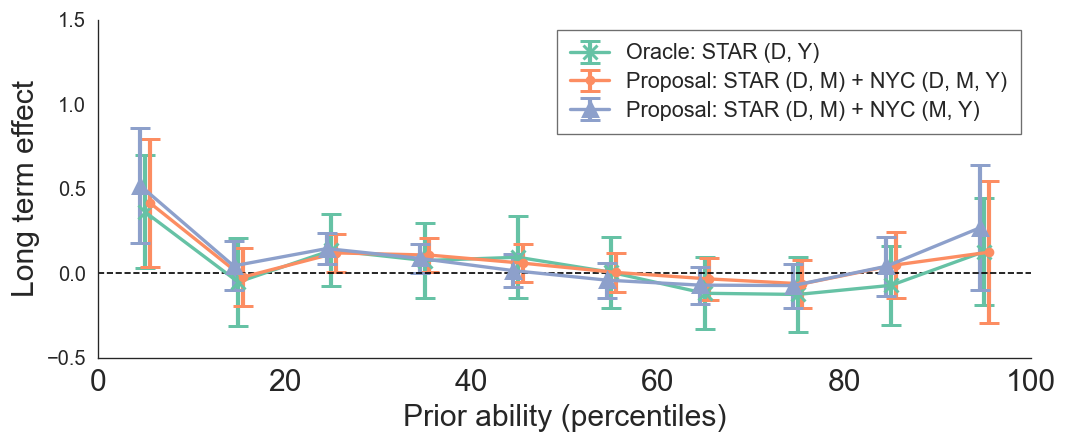

Saved figure -> ../output/plot_heterogeneous_z_score6_gau_simultaneous_rkhs.png
Rep: 1


100%|██████████| 5/5 [00:05<00:00,  1.09s/it]


Rep: 1


100%|██████████| 5/5 [00:04<00:00,  1.11it/s]


[PLOT] Heterogeneous — RKHS — Outcome: z_score7 -> ../output/plot_heterogeneous_z_score7_gau_simultaneous_rkhs.png


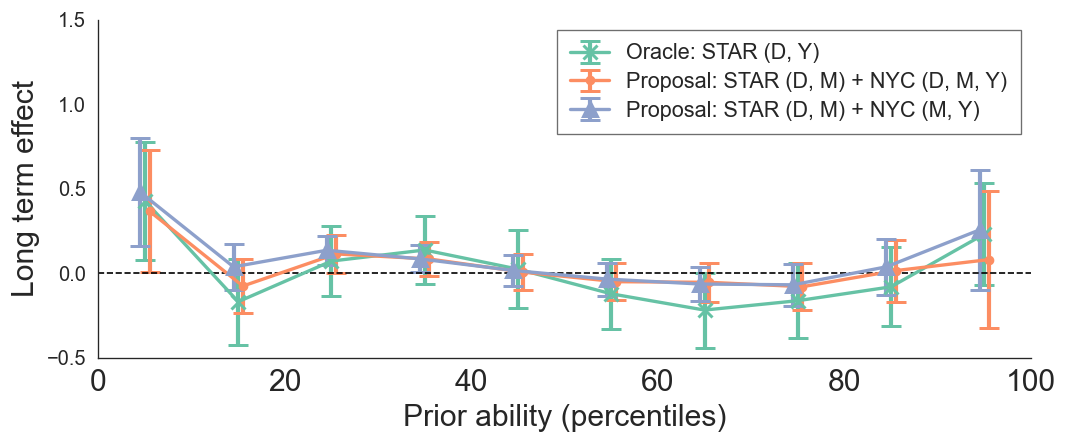

Saved figure -> ../output/plot_heterogeneous_z_score7_gau_simultaneous_rkhs.png
Rep: 1


100%|██████████| 5/5 [00:05<00:00,  1.09s/it]


Rep: 1


100%|██████████| 5/5 [00:04<00:00,  1.06it/s]


[PLOT] Heterogeneous — RKHS — Outcome: z_score8 -> ../output/plot_heterogeneous_z_score8_gau_simultaneous_rkhs.png


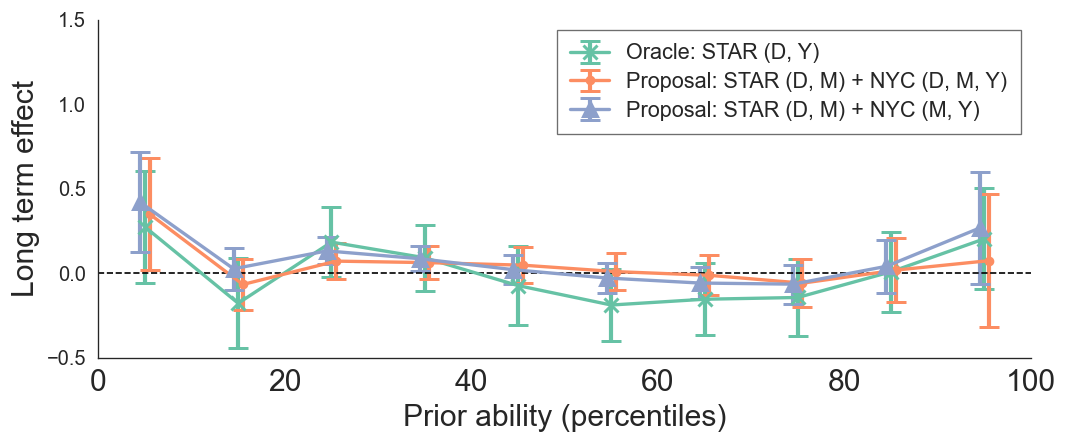

Saved figure -> ../output/plot_heterogeneous_z_score8_gau_simultaneous_rkhs.png
Saved heterogeneous (rkhs) -> ../output/heterogeneous_star_simultaneous_rkhs.csv
[TIMING] Simultaneous RKHS — Localized score curves finished in 1m 01.63s


In [8]:

# ---- Run localized score curves for simultaneous RKHS and neural models ----
with timer("Simultaneous RKHS — Localized score curves"):
    hetero_rkhs = run_heterogeneous_grid(
        df=df,
        outcome_cols=OUTCOME_LIST,
        mode="rkhs",
        loc_kernel="gau",
        percentiles=np.arange(5, 100, 10),
    )


Rep: 1


100%|██████████| 5/5 [08:12<00:00, 98.41s/it] 


Rep: 1


100%|██████████| 5/5 [04:08<00:00, 49.77s/it]


[PLOT] Heterogeneous — NN — Outcome: z_score3 -> ../output/plot_heterogeneous_z_score3_gau_simultaneous_nn.png


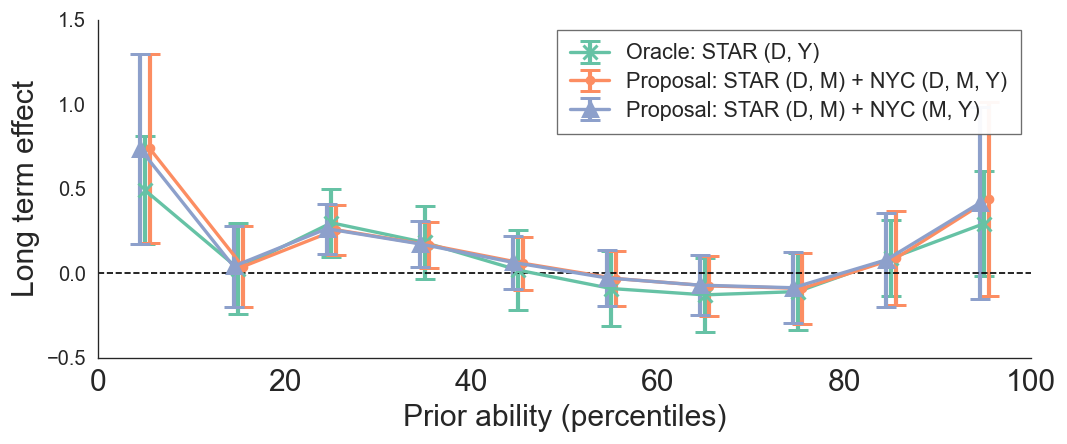

Saved figure -> ../output/plot_heterogeneous_z_score3_gau_simultaneous_nn.png
Rep: 1


100%|██████████| 5/5 [08:08<00:00, 97.65s/it]


Rep: 1


100%|██████████| 5/5 [04:07<00:00, 49.54s/it]


[PLOT] Heterogeneous — NN — Outcome: z_score4 -> ../output/plot_heterogeneous_z_score4_gau_simultaneous_nn.png


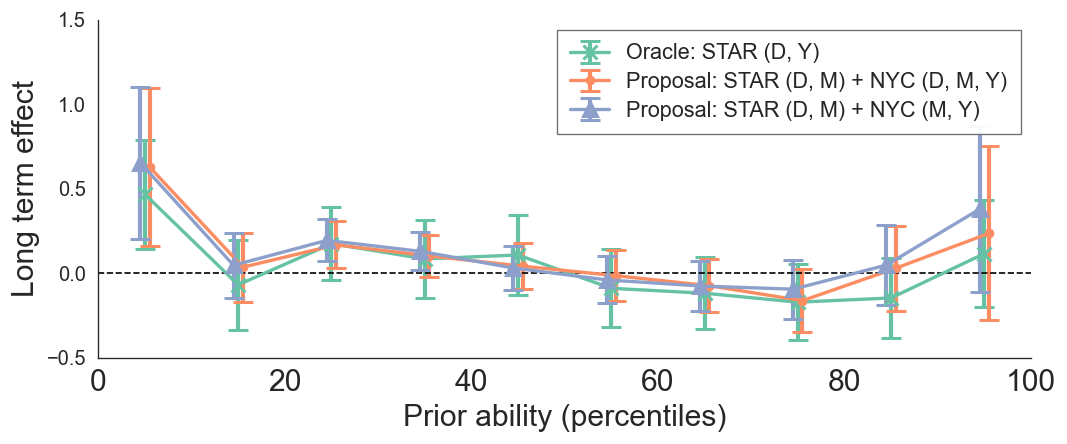

Saved figure -> ../output/plot_heterogeneous_z_score4_gau_simultaneous_nn.png
Rep: 1


100%|██████████| 5/5 [08:11<00:00, 98.27s/it]


Rep: 1


100%|██████████| 5/5 [13:41<00:00, 164.37s/it]


[PLOT] Heterogeneous — NN — Outcome: z_score5 -> ../output/plot_heterogeneous_z_score5_gau_simultaneous_nn.png


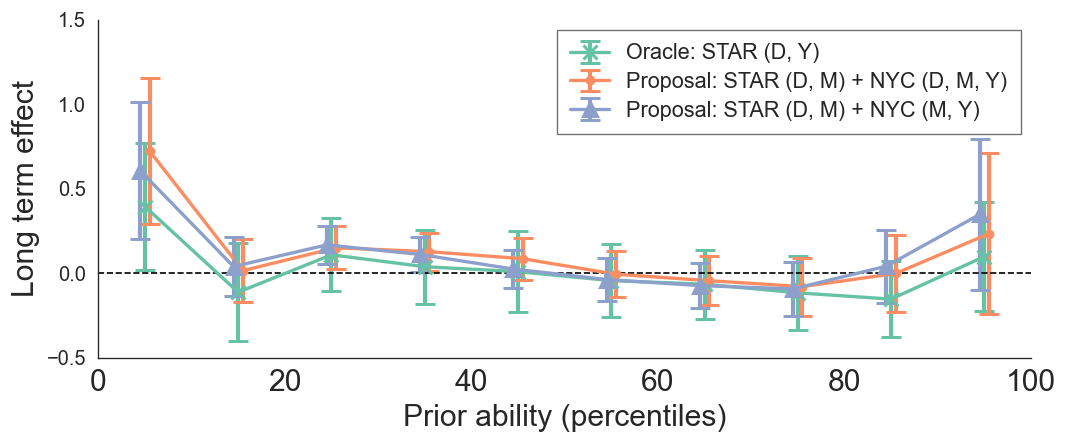

Saved figure -> ../output/plot_heterogeneous_z_score5_gau_simultaneous_nn.png
Rep: 1


100%|██████████| 5/5 [08:08<00:00, 97.67s/it]


Rep: 1


100%|██████████| 5/5 [04:10<00:00, 50.01s/it]


[PLOT] Heterogeneous — NN — Outcome: z_score6 -> ../output/plot_heterogeneous_z_score6_gau_simultaneous_nn.png


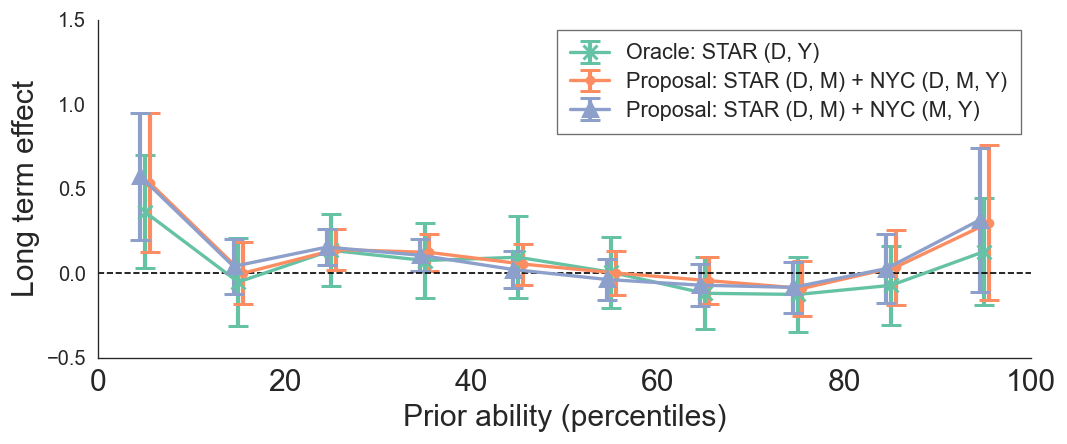

Saved figure -> ../output/plot_heterogeneous_z_score6_gau_simultaneous_nn.png
Rep: 1


100%|██████████| 5/5 [08:30<00:00, 102.10s/it]


Rep: 1


100%|██████████| 5/5 [04:14<00:00, 50.86s/it]


[PLOT] Heterogeneous — NN — Outcome: z_score7 -> ../output/plot_heterogeneous_z_score7_gau_simultaneous_nn.png


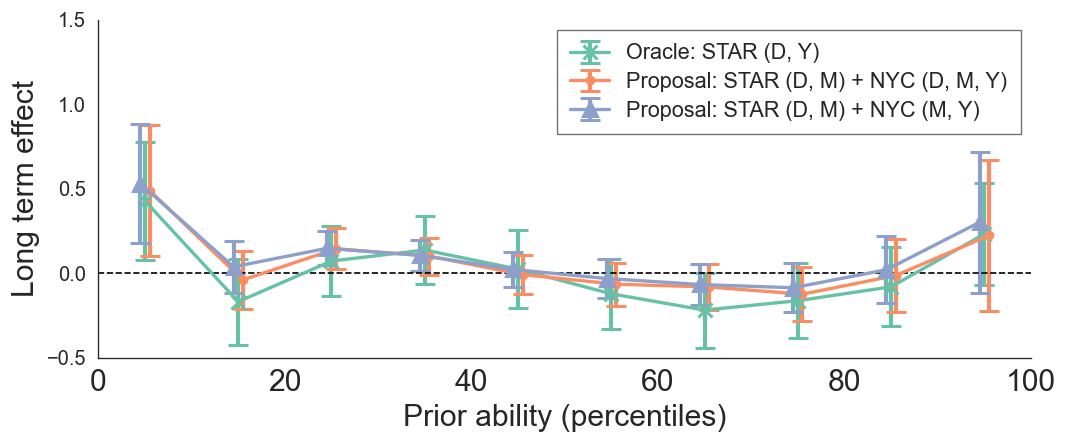

Saved figure -> ../output/plot_heterogeneous_z_score7_gau_simultaneous_nn.png
Rep: 1


100%|██████████| 5/5 [08:28<00:00, 101.78s/it]


Rep: 1


100%|██████████| 5/5 [04:20<00:00, 52.16s/it]


[PLOT] Heterogeneous — NN — Outcome: z_score8 -> ../output/plot_heterogeneous_z_score8_gau_simultaneous_nn.png


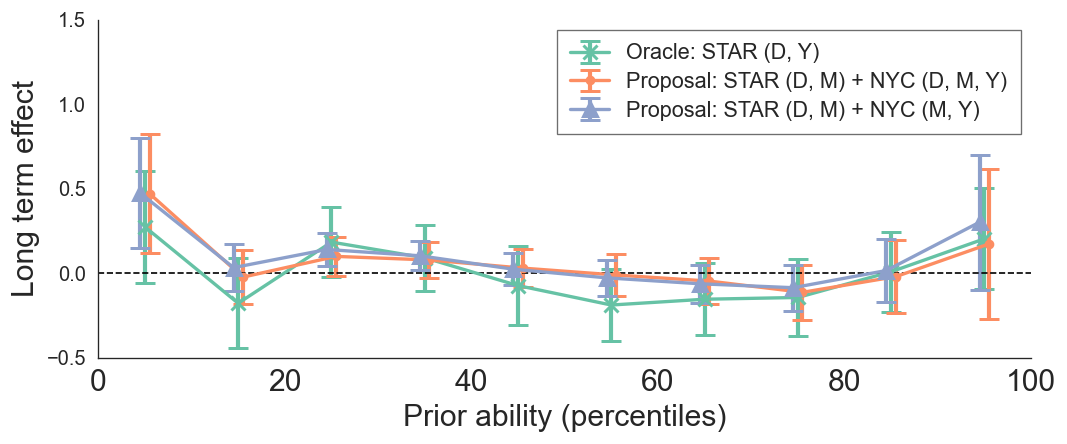

Saved figure -> ../output/plot_heterogeneous_z_score8_gau_simultaneous_nn.png
Saved heterogeneous (nn) -> ../output/heterogeneous_star_simultaneous_nn.csv
[TIMING] Simultaneous AGMM2L2 — Localized score curves finished in 75m 17.27s


In [9]:

with timer("Simultaneous AGMM2L2 — Localized score curves"):
    hetero_nn = run_heterogeneous_grid(
        df=df,
        outcome_cols=OUTCOME_LIST,
        mode="nn",
        loc_kernel="gau",
        percentiles=np.arange(5, 100, 10),
    )
